# In-Class Quiz Nº 2

<hr style="border:1px  solid black"> </hr>

### (Fill in)
## Name: Bruno Tavares Rodrigues
## Number: 52323

<hr style="border:1px  solid black"> </hr>

## Develop and run the requested code in the cells immediately below the questions.

# IMPORTANTE:
## Once completed, save this Jupyter notebook with the following name:
## Axxxxx-Q2.ipynb (Axxxxx: student number)
##  and then upload the file to the Moodle link provided for that purpose.

<hr style="border:2px solid black"> </hr>

# Data: CIFAR-10 (small version)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
#import keras
import tensorflow.keras as keras
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
#sem GPU, comentar as 2 linhas seguintes de código
gp=tf.config.list_physical_devices()
#tf.config.experimental.set_memory_growth(gp[0],True)
print(gp)
import tensorflow.keras.datasets.cifar10 as cifar10

(X1,y1),(X2,y2)=cifar10.load_data()
y1=y1.squeeze()
y2=y2.squeeze()


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
102391808/170498071 ━━━━━━━━━━━━━━━━━━━━ 5:43 5us/step

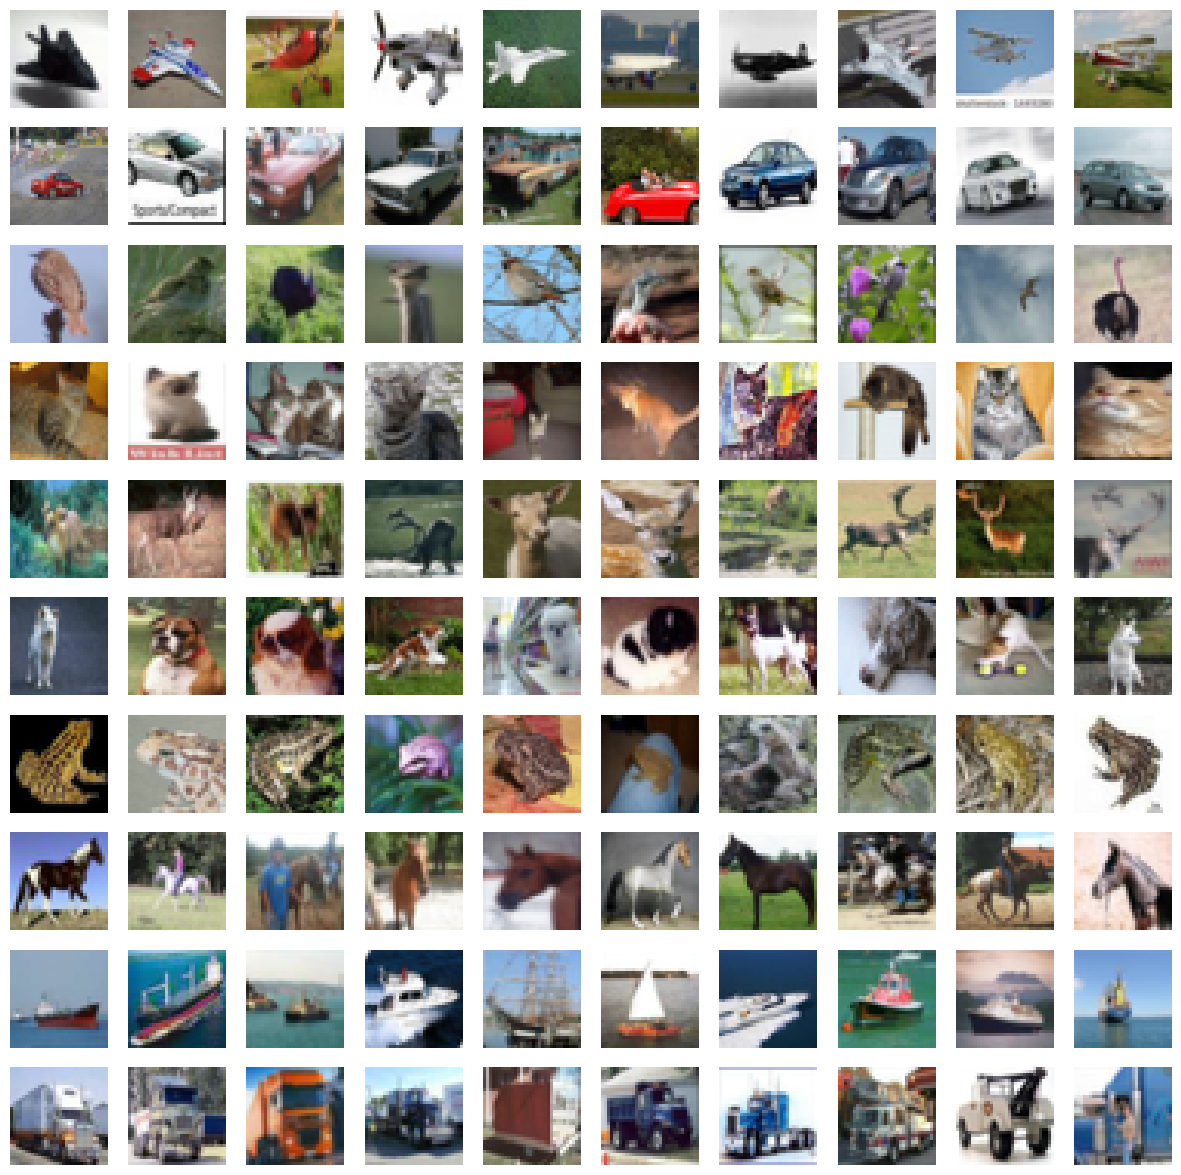

In [2]:
plt.figure(figsize=(15,15))
c=1
for i in range(10):
    for j in range(10):
        plt.subplot(10,10,c)
        c+=1
        A=X1[y1==i]
        plt.imshow(A[i*10+j,:])
        plt.axis('off')


# Question 1: 
### a) From the matrix X1, select a subset of 20000 images for training and  a subset of 10000 images for validation. Make sure that there are 2000 examples per class and that this new training data is shuffled, and that there are 1000 images per class in the validation set. Also make shure that the validation and test sets are ordered per class.
### b) Build (from scratch) a CNN with an architecture of your choice and with the following restrictions:
#### - Use 6 convolutional layers
#### - Use 3 pooling layers
###  Build this network, compile and train the network using the  training and validation sets. Plot the  the losses and the accuracies curves for the training and validation sets during the training process. Train the network for 25 epochs.  Comment the results. 
### c) Obtain the confusion matrix and the total number of erros in the test set.

## 1.a)

In [ ]:
X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []

for c in range(10):
    idx = np.where(y1 == c)[0]
    X_train_list.append(X1[idx[:2000]])
    y_train_list.append(y1[idx[:2000]])
    X_val_list.append(X1[idx[2000:3000]])
    y_val_list.append(y1[idx[2000:3000]])

X_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)
X_val   = np.concatenate(X_val_list)
y_val   = np.concatenate(y_val_list)

shuffle = np.random.permutation(len(X_train))
X_train, y_train = X_train[shuffle], y_train[shuffle]

sort = np.argsort(y2)
X_test, y_test = X2[sort], y2[sort]

print(f"Train : {X_train.shape}, classes: {np.unique(y_train, return_counts=True)[1]}")
print(f"Val   : {X_val.shape},   classes: {np.unique(y_val,   return_counts=True)[1]}")
print(f"Test  : {X_test.shape},  classes: {np.unique(y_test,  return_counts=True)[1]}")

## 1.b)

In [ ]:
# Normalize pixel values to [0, 1]
X_train_n = X_train / 255.0
X_val_n   = X_val   / 255.0
X_test_n  = X_test  / 255.0

# Build CNN: 6 conv layers + 3 pooling layers
model = keras.Sequential([
    # Block 1
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    # Block 2
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    # Block 3
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train_n, y_train,
                    epochs=25,
                    validation_data=(X_val_n, y_val))

# Plot loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()


## 1.c)

# Question 2
## Consider that we want to use transfer learning to build a CNN to tackle the problem. For the pre-trained CNN use MobileNetV2. Use only one hidden Dense layers with 64 'relu' units and one output layer for the top MLP network.
### a)  Build and compile this network. Justify our choices for the compilation parameters.
### b)  Train the network for 25 epochs and show the results. Print the confusion matrix and the total number of errors in the test set. Compare the results with the ones obtained in the previous question and state the possible reasons for the differences in performance.
### c)  Build 3 tensorflow generators, one for each subset: training,validation and test generator.  
###    Use the `tf.data.Dataset.from_tensor_slices` function to build the generators.  Make sure that the training generator shuffles the data but the validation and test ones do not. Also make sure that all generators do the  data pre-processing needed for the CNN network. Justify our choice of parameters for the 3 generators. 

## 2.a)

## 2.b)

## 2.c)

<hr style="border:2px solid black"> </hr>

<hr style="border:2px solid black"> </hr>

# The Harvard Flowers Dataset

# Question 3.
## Consider that we want to use transfer learning to build a CNN to tackle the problem. For the pre-trained CNN use MobileNetV2.
### a)  Build 3 tensorflow generators, one for each subset: training,validation and test. generator  
###     Use the `keras.utils.image_dataset_from_directory` function to build the generators. Use an image size of (100x100). Make sure that the training generator shuffles the data, and does data augmentation. Also make sure that all the generators apply the image pre-processing needed. Justify our choice of parameters for the 3 generators.
### b)  Build and compile this network. Justify our choices for the compilation parameters.
### c)  Train the network for at least 15 epochs and show the results. Print the confusion matrix and the total number of errors in the test set. Comment the results.

## 3.a)

## 3.b)

## 3.c)